In [55]:
import pandas as pd
import seaborn as sns
sns.set_theme()

In [56]:
df = pd.read_csv("metrics_v7.csv")

In [57]:
df = df[df["actual_val"]>0.0]

In [58]:
from matplotlib import pyplot as plt

In [59]:
unique_cond_values = df["cond_scale"].unique()

In [60]:
cond_dfs = []
for value in unique_cond_values:
    cond_dfs.append(df[df["cond_scale"]==value])

In [61]:
unique_column_values = cond_dfs[0]["column"].unique()

In [62]:
len(cond_dfs)

3

In [63]:
from sklearn.metrics import r2_score

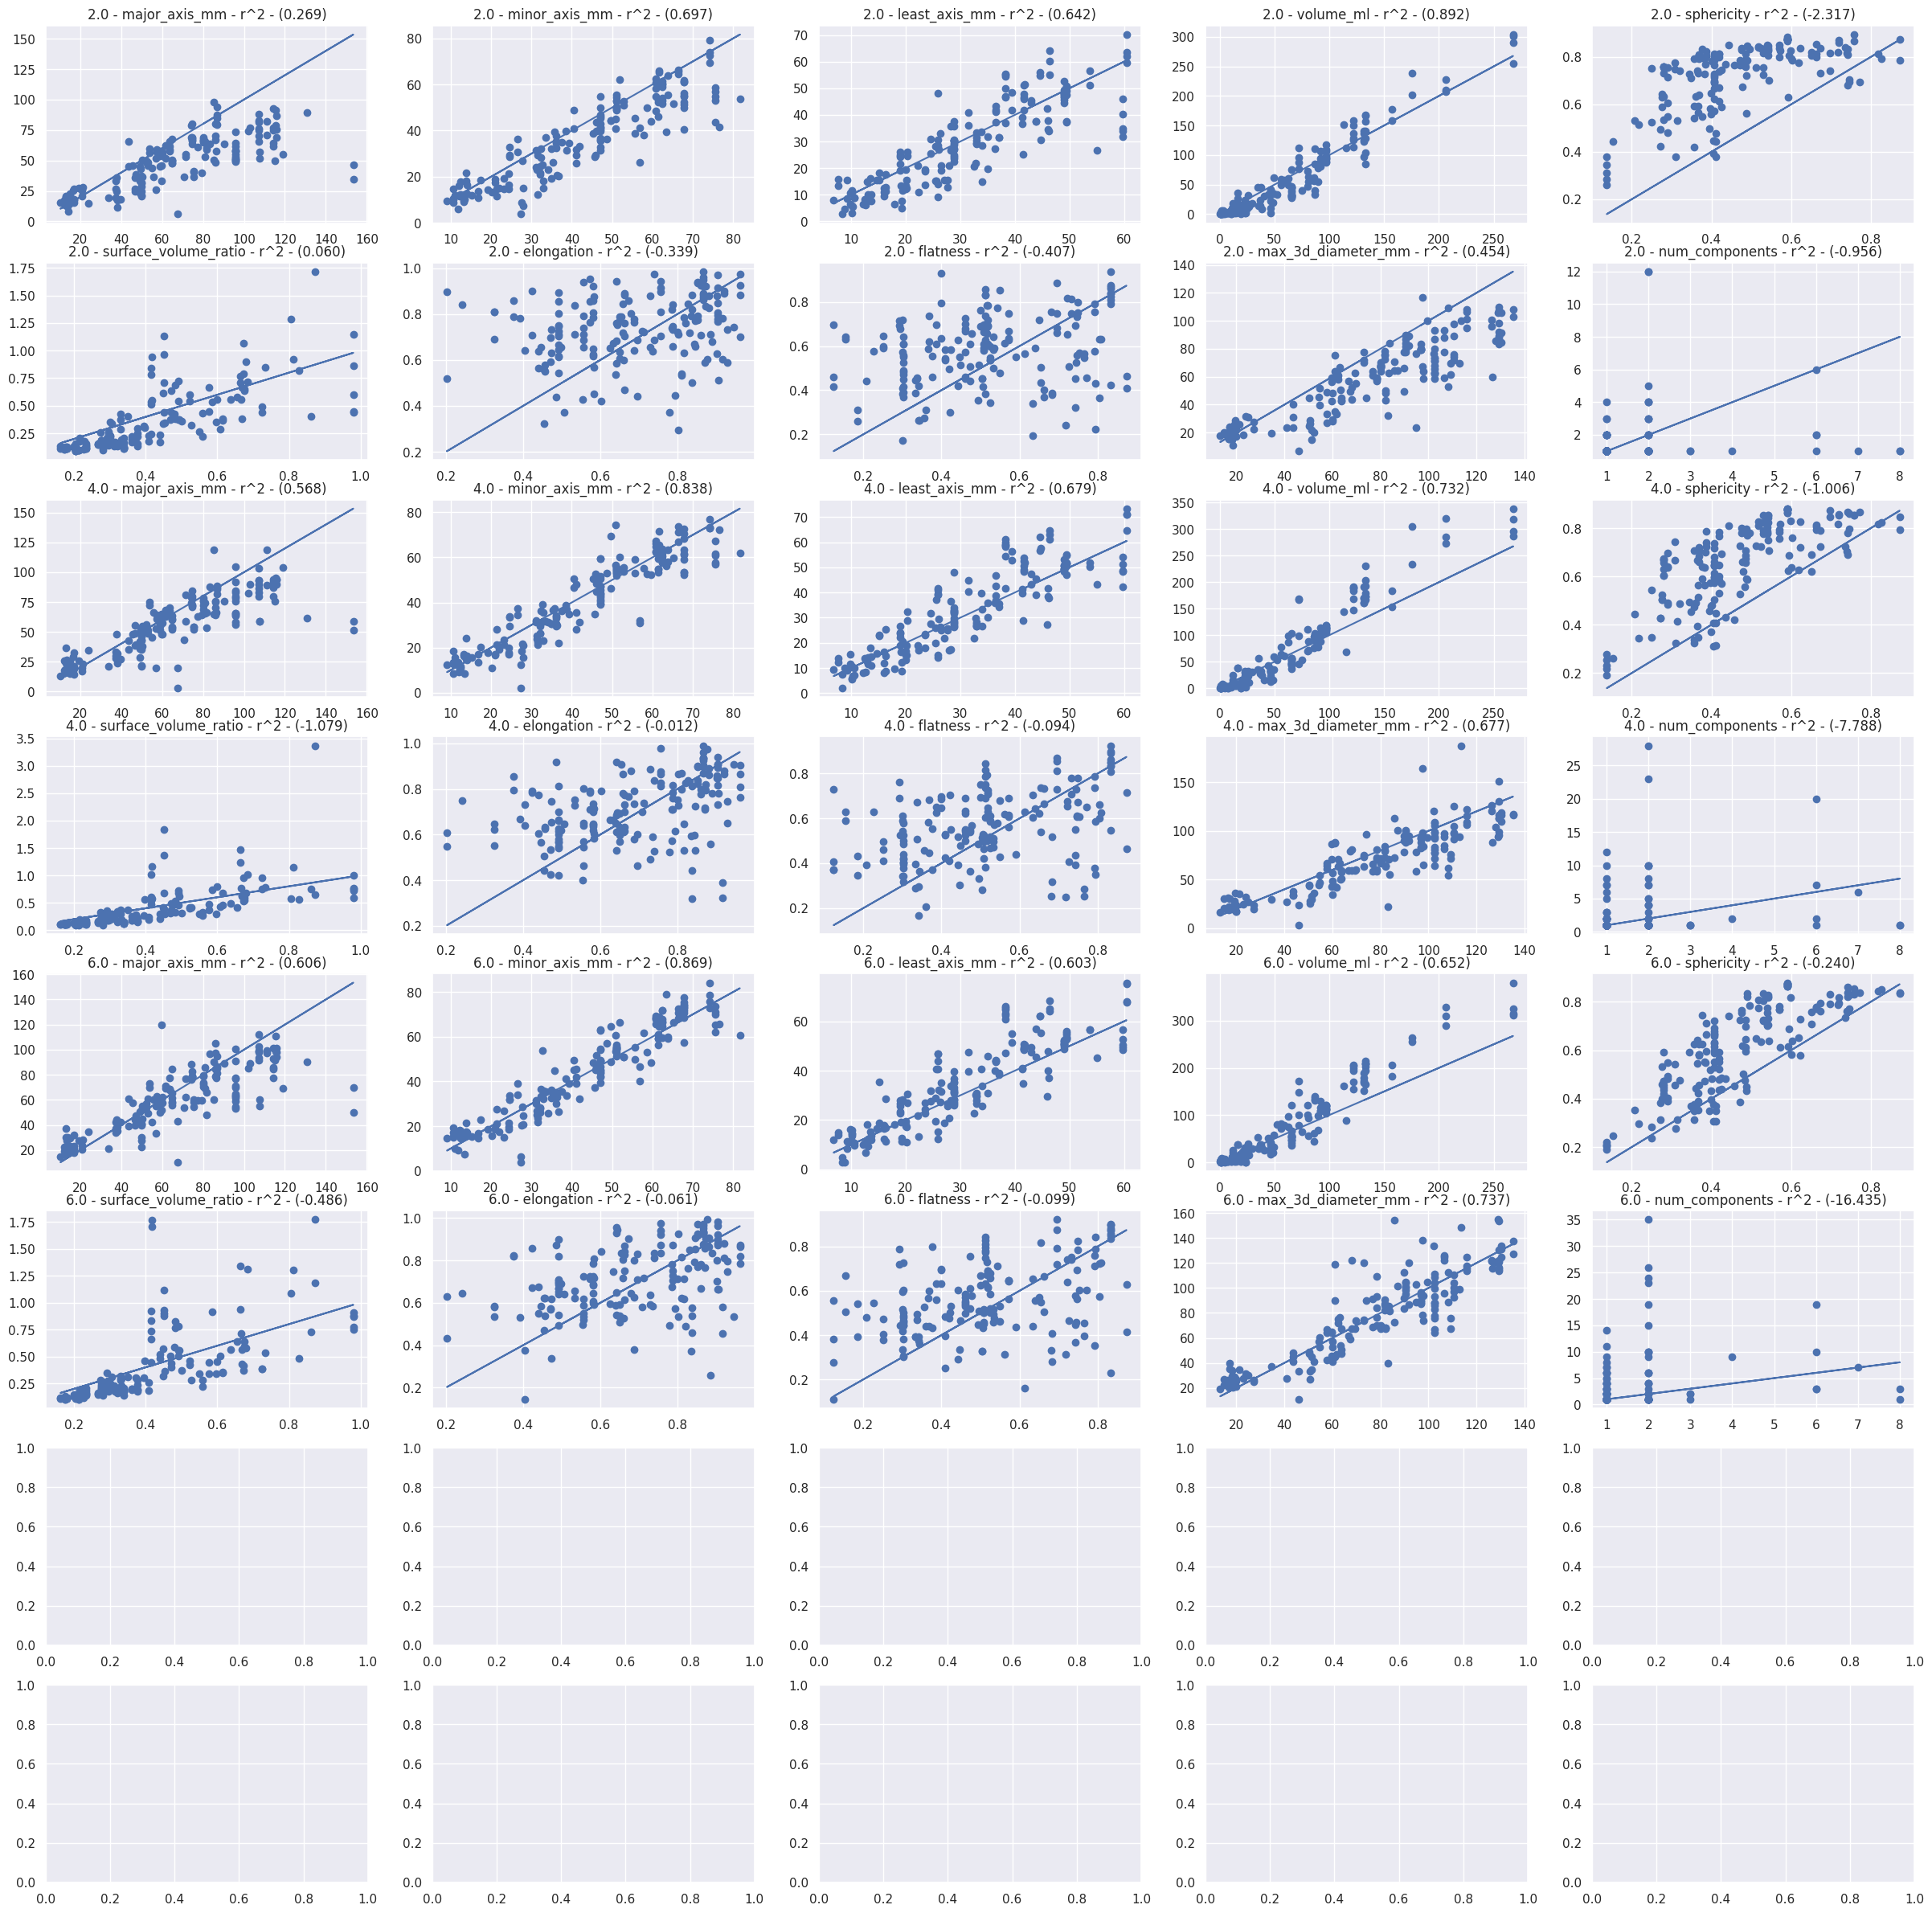

In [64]:
fig, ax = plt.subplots(8, 5, figsize=(30,30))
# Flatten the 2D array of axes into a 1D array of 40 elements
axes_flat = ax.flatten()
r2_vals = []

steps = 0
for i, cond in enumerate(cond_dfs):
    for j, col in enumerate(unique_column_values):
        # Prevent IndexError if your data exceeds 40 combinations
        if steps >= len(axes_flat):
            print("Warning: More data combinations than available subplots!")
            break
            
        col_rows = cond[cond["column"] == col]
        
        # Directly index the flattened axes
        current_ax = axes_flat[steps]
        
        current_ax.scatter(col_rows["desired_val"], col_rows["actual_val"])
        current_ax.plot(col_rows["desired_val"],col_rows["desired_val"])
        r2 = r2_score(col_rows["desired_val"], col_rows["actual_val"])
        current_ax.set_title(f"{unique_cond_values[i]} - {col} - r^2 - ({r2:.3f})")
        r2_vals.append({"r2":r2,"cond":unique_cond_values[i],"col":col})
        steps += 1

In [65]:
pd.DataFrame(r2_vals)

,r2,cond,col
0,0.269421,2.0,major_axis_mm
1,0.696985,2.0,minor_axis_mm
2,0.642426,2.0,least_axis_mm
3,0.892307,2.0,volume_ml
4,-2.317431,2.0,sphericity
5,0.059552,2.0,surface_volume_ratio
6,-0.338595,2.0,elongation
7,-0.406859,2.0,flatness
8,0.453599,2.0,max_3d_diameter_mm
9,-0.955512,2.0,num_components


In [66]:
for i, cond in enumerate(cond_dfs):
    for j, col in enumerate(unique_column_values):
        col_rows = cond[cond["column"] == col]
        print(f"Cond: {unique_cond_values[i]} - Col: {col}")
        r2 = r2_score(col_rows["desired_val"], col_rows["actual_val"])
        print(f"R^2: {r2}")
        percent_error = (abs(col_rows['desired_val']-col_rows['actual_val'])/col_rows['desired_val']).mean() * 100
        print(f"Percent error: {percent_error}")

        print(f"Stdev desired: {col_rows['desired_val'].std()}")
        print(f"Stdev actual: {col_rows['actual_val'].std()}")

        print("=============")

Cond: 2.0 - Col: major_axis_mm
R^2: 0.26942102856402805
Percent error: 27.325532414991233
Stdev desired: 31.324722338982554
Stdev actual: 21.467806966591308
Cond: 2.0 - Col: minor_axis_mm
R^2: 0.6969846695891866
Percent error: 19.484376198535465
Stdev desired: 19.017380081674744
Stdev actual: 17.794658416780813
Cond: 2.0 - Col: least_axis_mm
R^2: 0.642426446734257
Percent error: 23.390565261758
Stdev desired: 14.262426805242942
Stdev actual: 15.980817887094014
Cond: 2.0 - Col: volume_ml
R^2: 0.8923065179526674
Percent error: 40.04229830025807
Stdev desired: 58.0392745125201
Stdev actual: 65.62695696483486
Cond: 2.0 - Col: sphericity
R^2: -2.317430934954706
Percent error: 67.78103459109805
Stdev desired: 0.15788759645262937
Stdev actual: 0.13996460868859514
Cond: 2.0 - Col: surface_volume_ratio
R^2: 0.05955244760845946
Percent error: 36.936382569113654
Stdev desired: 0.19702359329387595
Stdev actual: 0.2761480788250853
Cond: 2.0 - Col: elongation
R^2: -0.3385953276190765
Percent error: 

In [67]:
from sklearn.metrics import r2_score

score = r2_score(df["desired_val"], df["actual_val"])

In [68]:
residuals = abs(df["desired_val"]-df["actual_val"])

In [69]:
plt.scatter(np.arange(0,len(residuals)),residuals)

NameError: name 'np' is not defined

In [ ]:
percent_error = residuals/df["desired_val"]

In [ ]:
df["percent_error"] = percent_error*100

/local/rpinise1/3754629/ipykernel_3169481/3553926432.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["percent_error"] = percent_error*100


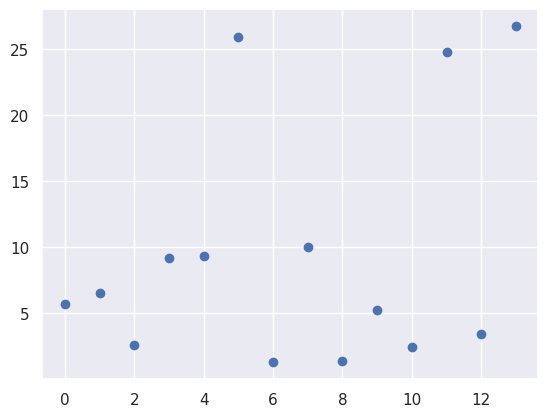

In [ ]:
plt.scatter(np.arange(0,len(df["percent_error"])),df["percent_error"])

In [ ]:
import numpy as np
from scipy import stats

def f_test_regression(y_true, y_pred, num_predictors=1):
    n = len(y_true)
    y_mean = np.mean(y_true)
    
    # Calculate Sum of Squares
    ss_reg = np.sum((y_pred - y_mean)**2)
    ss_res = np.sum((y_true - y_pred)**2)
    
    # Degrees of freedom
    df_reg = num_predictors
    df_res = n - num_predictors - 1
    
    # Mean Squares
    ms_reg = ss_reg / df_reg
    ms_res = ss_res / df_res
    
    # F-statistic
    f_stat = ms_reg / ms_res
    
    # P-value from F-distribution
    p_value = 1 - stats.f.cdf(f_stat, df_reg, df_res)
    
    return f_stat, p_value

# Usage
f_val, p_val = f_test_regression(df["desired_val"], df["actual_val"], num_predictors=1)
print(f"F-statistic: {f_val:.4f}, P-value: {p_val:.4e}")

F-statistic: 77.9043, P-value: 1.3557e-06


In [ ]:
df

,column,desired_val,actual_val,percent_error
1,volume_ml,4.662286,4.929,5.720676
2,volume_ml,0.517142,0.551,6.547129
3,volume_ml,57.272589,55.789,2.590399
4,volume_ml,13.027158,14.227,9.210309
5,volume_ml,11.737662,12.830,9.306263
6,volume_ml,1.089673,1.372,25.909385
7,volume_ml,1.089673,1.104,1.314841
8,volume_ml,57.272589,51.548,9.995338
9,volume_ml,29.671052,29.266,1.365141
10,volume_ml,12.503197,11.847,5.248232
